## Data Processing

In [2]:
# -*- coding: utf-8 -*-
# ============================================================
# ANES 2020 資料整理（Argyle Study 2 複製實驗用）
# ============================================================
# 這支程式做三件事：
#   1. 讀入 ANES 2020 原始資料
#   2. 排除 2016-2020 連續樣本（panel），只留 2020 新抽樣的受訪者
#   3. 只保留實驗需要的 11 個欄位，存成新檔案
#
# 重要原則：我們「不」清掉任何缺失值！
# Argyle 的做法是：某個變數缺失，就在 persona 描述裡省略那一句，
# 但這個人仍然保留在樣本中。所以資料裡的負值代碼（-9、-8...）
# 和特殊代碼（99 = 沒想過）都要原封不動留著，後面組裝 persona
# 的程式會自己判斷哪些句子要省略。
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 步驟 1：讀入原始資料
# ------------------------------------------------------------
# low_memory=False：檔案很大、欄位很多，讓 pandas 一次讀完，
# 避免同一欄被猜成不同型別。
df = pd.read_csv("anes_timeseries_2020_csv_20220210.csv", low_memory=False)

print("原始資料筆數：", len(df))   # 應該是 8,280

# ------------------------------------------------------------
# 步驟 2：排除 panel 受訪者
# ------------------------------------------------------------
# V200003 是「樣本類型」：
#   1 = 2020 年新抽樣的受訪者（我們要的）
#   2 = 2016 年受訪過、2020 年再訪的人（panel，要排除）
# 這是 Argyle 唯一做的樣本排除，我們照抄。
df = df[df["V200003"] != 2]

print("排除 panel 後筆數：", len(df))
# 我們這版資料會得到 5,441。
# Argyle 論文寫 5,442，差 1 筆是因為他們用的是 2021 年的早期
# 釋出版，資料版本不同。差 0.018%，對結果沒有影響，
# 已記入實驗的 deviation log，不需要處理。

# ------------------------------------------------------------
# 步驟 3：只保留實驗需要的 11 個欄位
# ------------------------------------------------------------
# 前 2 個是管理用欄位，中間 8 個是 persona 的條件變數
# （來自 Argyle 論文的模板），最後 1 個是要對答案用的結果變數。
keep = [
    "V200001",   # 受訪者編號（之後任何資料合併都靠它）
    "V200003",   # 樣本類型（留著方便日後查核）

    "V201549x",  # 種族/族裔
    "V202022",   # 是否與親友討論政治
    "V201200",   # 意識形態 7 點量表（99 = 沒想過，是有效答案！）
    "V201231x",  # 政黨認同 7 點量表
    "V201452",   # 是否參加宗教活動
    "V201507x",  # 年齡（80 = 80 歲以上都記成 80）
    "V201600",   # 性別
    "V202406",   # 政治興趣

    "V202110x",  # 2020 總統大選投給誰（1 = Biden，2 = Trump）
]
df = df[keep]

# ------------------------------------------------------------
# 步驟 4：看一眼結果變數的分布
# ------------------------------------------------------------
# 生成 persona 時 5,441 人全部都跑；
# 但最後比對答案時，只有真的投給 Biden 或 Trump 的人比得了。
print("\n投票結果分布（V202110x）：")
print(df["V202110x"].value_counts().sort_index())
print("\n說明：1 = Biden、2 = Trump、3~5 = 第三方候選人、")
print("負值 = 沒投票或沒回答。可比對的樣本 = 1 和 2 的合計。")

# ------------------------------------------------------------
# 步驟 5：存檔
# ------------------------------------------------------------
# encoding="utf-8-sig"：讓 Excel 打開時中文不會亂碼。
df.to_csv("anes2020_study2_frozen.csv", index=False, encoding="utf-8-sig")

print("\n完成！已存成 anes2020_study2_frozen.csv，共", len(df), "筆、", len(keep), "個欄位。")

原始資料筆數： 8280
排除 panel 後筆數： 5441

投票結果分布（V202110x）：
V202110x
-9      60
-8       1
-1    1367
 1    2297
 2    1608
 3      45
 4      17
 5      46
Name: count, dtype: int64

說明：1 = Biden、2 = Trump、3~5 = 第三方候選人、
負值 = 沒投票或沒回答。可比對的樣本 = 1 和 2 的合計。

完成！已存成 anes2020_study2_frozen.csv，共 5441 筆、 11 個欄位。


## Pilot B v1

In [ ]:
# -*- coding: utf-8 -*-
# ============================================================
# Pilot B：測試 gpt-5.6 能不能走 Argyle 的「機率讀出」路線
# ============================================================
# 目的（跑 20 個 persona 就夠回答）：
#   Q1. gpt-5.6 在 reasoning effort = none 之下，logprobs 參數能不能用？
#   Q2. 能用的話，首 token 的機率分布有沒有落在 trump / biden 的
#       token set 上？（落不上，機率法就沒有意義）
#   Q3. 對照組：直接讓它生成短文字，答案解析得出來嗎？
#
# 執行前：
#   pip install openai --upgrade
#   設好環境變數 OPENAI_API_KEY
#   本檔和 anes2020_study2_frozen.csv 放同一目錄
#
# 輸出：
#   pilot_b_results.csv （20 人 × 兩條路線的完整結果）
#   螢幕上的診斷摘要
# ============================================================

import os
os.environ["OPENAI_API_KEY"] = ""

import json
import math
import pandas as pd
from openai import OpenAI

# ---------------- 設定 ----------------
MODEL = "gpt-5.6"
N_PILOT = 20
SEED = 42                     # 固定亂數種子，抽到的 20 人可重現
DATA_FILE = "anes2020_study2_frozen.csv"
OUT_FILE = "pilot_b_results.csv"

client = OpenAI()

# ============================================================
# 第一部分：backstory 模板（逐句翻寫自 Argyle 的 anes2020.py）
# ============================================================
# 句子順序、用字、甚至大小寫的不一致（"a strong democrat" 小寫、
# "a weak Democrat" 大寫）都照抄——完全複製的紀律。
# 規則：變數值不在對照表裡（負值、99），該句省略，人保留。

RACE = {1: "white", 2: "black", 3: "asian", 4: "native American", 5: "hispanic"}
DISCUSS = {1: "I like to discuss politics with my family and friends.",
           2: "I never discuss politics with my family or friends."}
IDEO = {1: "extremely liberal", 2: "liberal", 3: "slightly liberal",
        4: "moderate", 5: "slightly conservative", 6: "conservative",
        7: "extremely conservative"}
PARTY = {1: "a strong democrat", 2: "a weak Democrat",
         3: "an independent who leans Democratic", 4: "an independent",
         5: "an independent who leans Republican", 6: "a weak Republican",
         7: "a strong Republican"}
CHURCH = {1: "attend church", 2: "do not attend church"}
GENDER = {1: "man", 2: "woman"}
INTEREST = {1: "very", 2: "somewhat", 3: "not very", 4: "not at all"}

# Argyle 2020 版的 prompt 結尾（含候選人提示句，一字不改）
QUERY = ("In the 2020 presidential election, Donald Trump is the Republican "
         "candidate, and Joe Biden is the Democratic candidate, and I voted for")


def gen_backstory(row):
    """把一位受訪者的變數組裝成 first-person backstory。順序照 Argyle。"""
    parts = []
    if row["V201549x"] in RACE:
        parts.append(f"Racially, I am {RACE[row['V201549x']]}.")
    if row["V202022"] in DISCUSS:
        parts.append(DISCUSS[row["V202022"]])
    if row["V201200"] in IDEO:                    # 99 不在表裡 → 自動省略
        parts.append(f"Ideologically, I am {IDEO[row['V201200']]}.")
    if row["V201231x"] in PARTY:
        parts.append(f"Politically, I am {PARTY[row['V201231x']]}.")
    if row["V201452"] in CHURCH:
        parts.append(f"I {CHURCH[row['V201452']]}.")
    # 注意：Argyle 的程式碼對年齡「不檢查有效性」，缺失代碼 -9 也會
    # 直接寫成 "I am -9 years old."。這裡先照抄他的行為；
    # 要不要修，等 pilot 看完再決定（見執行後的討論）。
    parts.append(f"I am {row['V201507x']} years old.")
    if row["V201600"] in GENDER:
        parts.append(f"I am a {GENDER[row['V201600']]}.")
    if row["V202406"] in INTEREST:
        parts.append(f"I am {INTEREST[row['V202406']]} interested in politics.")
    return " ".join(parts)


# ============================================================
# 第二部分：token set（照抄 Argyle 2020 版）與機率合併
# ============================================================
TRUMP_WORDS = {"donald", "trump", "republican", "conservative"}
BIDEN_WORDS = {"joe", "joseph", "biden", "democrat", "democratic", "liberal"}


def classify_token(tok):
    """判斷一個 token 屬於哪個 token set（比對時去空白、轉小寫）。"""
    t = tok.strip().lower()
    if t in TRUMP_WORDS:
        return "trump"
    if t in BIDEN_WORDS:
        return "biden"
    return None


def probs_from_logprobs(top_logprobs):
    """
    top_logprobs：[{token, logprob}, ...]，首 token 位置的前 20 名。
    把落在兩個 token set 的機率各自加總，再歸一化（Argyle 的做法）。
    """
    p = {"trump": 0.0, "biden": 0.0}
    seen = []
    for item in top_logprobs:
        side = classify_token(item["token"])
        seen.append((item["token"], round(math.exp(item["logprob"]), 4), side))
        if side:
            p[side] += math.exp(item["logprob"])
    total = p["trump"] + p["biden"]
    if total == 0:
        return None, None, seen      # 前 20 名完全沒有候選人 token → 機率法失敗
    return p["trump"] / total, p["biden"] / total, seen


# ============================================================
# 第三部分：兩條 API 路線
# ============================================================
def route_logprobs(prompt):
    """路線一：Chat Completions + logprobs。回傳 (p_trump, p_biden, 前20名, 錯誤訊息)"""
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            reasoning_effort="none",
            logprobs=True,
            top_logprobs=20,          # 現代 API 上限通常是 20（Argyle 當年拿得到 100）
            max_completion_tokens=4,
        )
        first = resp.choices[0].logprobs.content[0]
        top = [{"token": t.token, "logprob": t.logprob} for t in first.top_logprobs]
        p_t, p_b, seen = probs_from_logprobs(top)
        return p_t, p_b, seen, None
    except Exception as e:
        return None, None, None, str(e)


def route_text(prompt):
    """路線二：直接生成短文字，再解析。回傳 (原文, 解析結果, 錯誤訊息)"""
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            reasoning_effort="none",
            max_completion_tokens=16,
        )
        text = resp.choices[0].message.content or ""
        low = text.lower()
        has_t = any(w in low for w in TRUMP_WORDS)
        has_b = any(w in low for w in BIDEN_WORDS)
        if has_t and not has_b:
            vote = "trump"
        elif has_b and not has_t:
            vote = "biden"
        else:
            vote = "unclear"          # 兩邊都有或都沒有 → 需人工看原文
        return text, vote, None
    except Exception as e:
        return "", "error", str(e)


# ============================================================
# 主流程
# ============================================================
def main():
    df = pd.read_csv(DATA_FILE)
    pilot = df.sample(N_PILOT, random_state=SEED).reset_index(drop=True)

    rows = []
    for i, row in pilot.iterrows():
        prompt = gen_backstory(row) + " " + QUERY
        print(f"\n===== 第 {i+1}/{N_PILOT} 人（ID {row['V200001']}）=====")
        print(prompt)

        p_t, p_b, seen, err1 = route_logprobs(prompt)
        if err1:
            print("  [機率路線] 失敗：", err1)
        else:
            print(f"  [機率路線] P(Trump)={p_t}  P(Biden)={p_b}" if p_t is not None
                  else "  [機率路線] API 有回 logprobs，但前 20 名沒有候選人 token！")
            print("  首 token 前 20 名：", seen)

        text, vote, err2 = route_text(prompt)
        print(f"  [文字路線] 生成：{text!r} → 解析為 {vote}" if not err2
              else f"  [文字路線] 失敗：{err2}")

        rows.append({
            "V200001": row["V200001"],
            "backstory_prompt": prompt,
            "anes_vote": row["V202110x"],          # 1=Biden 2=Trump（其他值不比對）
            "p_trump": p_t, "p_biden": p_b,
            "logprob_top20": json.dumps(seen, ensure_ascii=False) if seen else "",
            "logprob_error": err1 or "",
            "text_output": text, "text_vote": vote, "text_error": err2 or "",
        })

    out = pd.DataFrame(rows)
    out.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

    # ---------------- 診斷摘要 ----------------
    print("\n" + "=" * 50)
    print("Pilot B 診斷摘要")
    print("=" * 50)
    n_lp_ok = out["p_trump"].notna().sum()
    n_lp_err = (out["logprob_error"] != "").sum()
    print(f"機率路線成功（有候選人 token 的機率）：{n_lp_ok}/{N_PILOT}")
    print(f"機率路線出錯（API 拒絕或例外）      ：{n_lp_err}/{N_PILOT}")
    print(f"文字路線解析結果：{out['text_vote'].value_counts().to_dict()}")

    both = out[(out["p_trump"].notna()) & (out["text_vote"].isin(["trump", "biden"]))]
    if len(both) > 0:
        agree = ((both["p_trump"] > 0.5) == (both["text_vote"] == "trump")).mean()
        print(f"兩條路線判定一致率：{agree:.0%}（n={len(both)}）")
    print(f"\n完整結果已存：{OUT_FILE}")
    print("判讀規則：機率路線 20/20 成功 → 全量跑用機率法（最接近 Argyle）；")
    print("　　　　　部分成功或 token 對不上 → 帶著摘要回來討論；")
    print("　　　　　全數失敗 → 全量跑落到文字法，記一條 deviation。")


if __name__ == "__main__":
    main()


===== 第 1/20 人（ID 334932）=====
I like to discuss politics with my family and friends. Ideologically, I am liberal. Politically, I am a strong democrat. I do not attend church. I am 20 years old. I am a man. I am very interested in politics. In the 2020 presidential election, Donald Trump is the Republican candidate, and Joe Biden is the Democratic candidate, and I voted for
  [機率路線] 失敗： Error code: 400 - {'error': {'message': "Invalid value for 'top_logprobs': must be less than or equal to 5.", 'type': 'invalid_request_error', 'param': 'top_logprobs', 'code': None}}
  [文字路線] 生成：'Joe Biden.' → 解析為 biden

===== 第 2/20 人（ID 504137）=====
Racially, I am white. I like to discuss politics with my family and friends. Ideologically, I am moderate. Politically, I am a strong Republican. I do not attend church. I am 54 years old. I am a woman. I am somewhat interested in politics. In the 2020 presidential election, Donald Trump is the Republican candidate, and Joe Biden is the Democratic candida

## Pilot B v2

In [ ]:
# -*- coding: utf-8 -*-
# ============================================================
# Pilot B v2：2×2 設計，驗證「續寫指令」修法
# ============================================================
# v1 的兩個發現：
#   1. top_logprobs 上限是 5（不是拒絕 logprobs）→ 改成 5 再測
#   2. chat 模型會拒答（「我不能猜你投給誰」），且疑似集中在
#      弱政黨認同者 → 補一句中性的續寫指令，把任務框架從
#      「猜使用者投票」翻譯回 Argyle 原本的「續寫第一人稱文字」
#
# 2×2 設計：
#   {機率路線, 文字路線} × {裸跑, 加續寫指令}
#   同樣的 20 人（同 SEED），每人 4 次呼叫，共 80 次。
#
# 三個放行條件（全過 → 全量規格凍結為「機率法＋續寫指令」）：
#   A. 加指令後拒答消失
#   B. 裸跑就有答案的人，加指令後答案不變（指令沒偷改內容）
#   C. 機率路線前 5 名出現候選人 token
# ============================================================

import os
os.environ["OPENAI_API_KEY"] = ""

import json
import math
import pandas as pd
from openai import OpenAI

# ---------------- 設定 ----------------
MODEL = "gpt-5.6"
N_PILOT = 20
SEED = 42                     # 跟 v1 同一批 20 人
TOP_LOGPROBS = 5              # v1 實測的 API 上限
DATA_FILE = "anes2020_study2_frozen.csv"
OUT_FILE = "pilot_b_v2_results.csv"

# 續寫指令：只翻譯任務框架，一個字都不碰 backstory 與 persona 內容
SYSTEM_CONTINUE = "Complete the following text."

client = OpenAI()

# ============================================================
# backstory 模板（與 v1 完全相同，翻寫自 Argyle anes2020.py）
# ============================================================
RACE = {1: "white", 2: "black", 3: "asian", 4: "native American", 5: "hispanic"}
DISCUSS = {1: "I like to discuss politics with my family and friends.",
           2: "I never discuss politics with my family or friends."}
IDEO = {1: "extremely liberal", 2: "liberal", 3: "slightly liberal",
        4: "moderate", 5: "slightly conservative", 6: "conservative",
        7: "extremely conservative"}
PARTY = {1: "a strong democrat", 2: "a weak Democrat",
         3: "an independent who leans Democratic", 4: "an independent",
         5: "an independent who leans Republican", 6: "a weak Republican",
         7: "a strong Republican"}
CHURCH = {1: "attend church", 2: "do not attend church"}
GENDER = {1: "man", 2: "woman"}
INTEREST = {1: "very", 2: "somewhat", 3: "not very", 4: "not at all"}

QUERY = ("In the 2020 presidential election, Donald Trump is the Republican "
         "candidate, and Joe Biden is the Democratic candidate, and I voted for")


def gen_backstory(row):
    parts = []
    if row["V201549x"] in RACE:
        parts.append(f"Racially, I am {RACE[row['V201549x']]}.")
    if row["V202022"] in DISCUSS:
        parts.append(DISCUSS[row["V202022"]])
    if row["V201200"] in IDEO:
        parts.append(f"Ideologically, I am {IDEO[row['V201200']]}.")
    if row["V201231x"] in PARTY:
        parts.append(f"Politically, I am {PARTY[row['V201231x']]}.")
    if row["V201452"] in CHURCH:
        parts.append(f"I {CHURCH[row['V201452']]}.")
    parts.append(f"I am {row['V201507x']} years old.")   # 照抄 Argyle：不檢查有效性
    if row["V201600"] in GENDER:
        parts.append(f"I am a {GENDER[row['V201600']]}.")
    if row["V202406"] in INTEREST:
        parts.append(f"I am {INTEREST[row['V202406']]} interested in politics.")
    return " ".join(parts)


# ============================================================
# token set 與機率合併（與 v1 相同）
# ============================================================
TRUMP_WORDS = {"donald", "trump", "republican", "conservative"}
BIDEN_WORDS = {"joe", "joseph", "biden", "democrat", "democratic", "liberal"}


def classify_token(tok):
    t = tok.strip().lower()
    if t in TRUMP_WORDS:
        return "trump"
    if t in BIDEN_WORDS:
        return "biden"
    return None


def probs_from_logprobs(top_logprobs):
    p = {"trump": 0.0, "biden": 0.0}
    seen = []
    for item in top_logprobs:
        side = classify_token(item["token"])
        seen.append((item["token"], round(math.exp(item["logprob"]), 4), side))
        if side:
            p[side] += math.exp(item["logprob"])
    total = p["trump"] + p["biden"]
    if total == 0:
        return None, None, seen
    return p["trump"] / total, p["biden"] / total, seen


def parse_text_vote(text):
    low = (text or "").lower()
    has_t = any(w in low for w in TRUMP_WORDS)
    has_b = any(w in low for w in BIDEN_WORDS)
    if has_t and not has_b:
        return "trump"
    if has_b and not has_t:
        return "biden"
    return "unclear"


# ============================================================
# 兩條路線（with_instruction 控制是否加續寫指令）
# ============================================================
def build_messages(prompt, with_instruction):
    msgs = []
    if with_instruction:
        msgs.append({"role": "system", "content": SYSTEM_CONTINUE})
    msgs.append({"role": "user", "content": prompt})
    return msgs


def route_logprobs(prompt, with_instruction):
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=build_messages(prompt, with_instruction),
            reasoning_effort="none",
            logprobs=True,
            top_logprobs=TOP_LOGPROBS,
            max_completion_tokens=4,
        )
        first = resp.choices[0].logprobs.content[0]
        top = [{"token": t.token, "logprob": t.logprob} for t in first.top_logprobs]
        p_t, p_b, seen = probs_from_logprobs(top)
        return p_t, p_b, seen, None
    except Exception as e:
        return None, None, None, str(e)


def route_text(prompt, with_instruction):
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=build_messages(prompt, with_instruction),
            reasoning_effort="none",
            max_completion_tokens=16,
        )
        text = resp.choices[0].message.content or ""
        return text, parse_text_vote(text), None
    except Exception as e:
        return "", "error", str(e)


# ============================================================
# 主流程
# ============================================================
def main():
    df = pd.read_csv(DATA_FILE)
    pilot = df.sample(N_PILOT, random_state=SEED).reset_index(drop=True)

    rows = []
    for i, row in pilot.iterrows():
        prompt = gen_backstory(row) + " " + QUERY
        print(f"\n===== 第 {i+1}/{N_PILOT} 人（ID {row['V200001']}）=====")

        rec = {"V200001": row["V200001"], "anes_vote": row["V202110x"],
               "backstory_prompt": prompt}

        for cond, label in [(False, "bare"), (True, "instr")]:
            p_t, p_b, seen, err1 = route_logprobs(prompt, cond)
            text, vote, err2 = route_text(prompt, cond)
            rec[f"p_trump_{label}"] = p_t
            rec[f"p_biden_{label}"] = p_b
            rec[f"top5_{label}"] = json.dumps(seen, ensure_ascii=False) if seen else ""
            rec[f"lp_error_{label}"] = err1 or ""
            rec[f"text_{label}"] = text
            rec[f"vote_{label}"] = vote
            rec[f"text_error_{label}"] = err2 or ""
            tag = "加指令" if cond else "裸跑　"
            lp_show = (f"P(T)={p_t:.3f}" if p_t is not None
                       else ("top5無候選人token" if not err1 else f"錯誤:{err1[:60]}"))
            print(f"  [{tag}] 機率:{lp_show} ｜ 文字:{text!r} → {vote}")

        rows.append(rec)

    out = pd.DataFrame(rows)
    out.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

    # ---------------- 三個放行條件的自動判讀 ----------------
    print("\n" + "=" * 50)
    print("Pilot B v2 診斷摘要（三個放行條件）")
    print("=" * 50)

    # 條件 A：加指令後拒答消失
    n_unclear_bare = (out["vote_bare"] == "unclear").sum()
    n_unclear_instr = (out["vote_instr"] == "unclear").sum()
    print(f"[A] 文字路線 unclear：裸跑 {n_unclear_bare} 人 → 加指令 {n_unclear_instr} 人"
          f"　{'✓ 通過' if n_unclear_instr == 0 else '✗ 未通過，看原文'}")

    # 條件 B：裸跑有答案者，加指令後答案不變
    answered = out[out["vote_bare"].isin(["trump", "biden"])]
    if len(answered) > 0:
        same = (answered["vote_bare"] == answered["vote_instr"]).sum()
        print(f"[B] 裸跑有答案 {len(answered)} 人中，加指令後答案不變 {same} 人"
              f"　{'✓ 通過' if same == len(answered) else '✗ 有人變了，逐筆檢查'}")

    # 條件 C：機率路線前 5 名有候選人 token（加指令版）
    n_lp_ok = out["p_trump_instr"].notna().sum()
    n_lp_err = (out["lp_error_instr"] != "").sum()
    print(f"[C] 機率路線（加指令）成功：{n_lp_ok}/{N_PILOT}"
          f"（API 錯誤 {n_lp_err} 筆）　{'✓ 通過' if n_lp_ok == N_PILOT else '✗ 未全過'}")

    # 附加資訊：機率 vs 文字的判定一致率（加指令版）
    both = out[(out["p_trump_instr"].notna()) & (out["vote_instr"].isin(["trump", "biden"]))]
    if len(both) > 0:
        agree = ((both["p_trump_instr"] > 0.5) == (both["vote_instr"] == "trump")).mean()
        print(f"[附] 機率法 vs 文字法判定一致率：{agree:.0%}（n={len(both)}）")

    print(f"\n完整結果已存：{OUT_FILE}")
    print("A、B、C 三條全過 → 全量規格凍結為「機率法＋續寫指令＋top_logprobs=5」")


if __name__ == "__main__":
    main()


===== 第 1/20 人（ID 334932）=====
  [裸跑　] 機率:P(T)=0.000 ｜ 文字:'Joe Biden.' → biden
  [加指令] 機率:P(T)=0.000 ｜ 文字:'Joe Biden.' → biden

===== 第 2/20 人（ID 504137）=====
  [裸跑　] 機率:P(T)=1.000 ｜ 文字:'Based on the information provided, you most likely voted for **Donald' → trump
  [加指令] 機率:P(T)=1.000 ｜ 文字:'Donald Trump.' → trump

===== 第 3/20 人（ID 312291）=====
  [裸跑　] 機率:top5無候選人token ｜ 文字:'The information is contradictory and insufficient to determine whom you voted for.' → unclear
  [加指令] 機率:P(T)=0.000 ｜ 文字:'Joe Biden.' → biden

===== 第 4/20 人（ID 515311）=====
  [裸跑　] 機率:top5無候選人token ｜ 文字:'Sorry, I can’t infer or guess who you voted for based' → unclear
  [加指令] 機率:P(T)=0.234 ｜ 文字:'Joe Biden.' → biden

===== 第 5/20 人（ID 411983）=====
  [裸跑　] 機率:P(T)=1.000 ｜ 文字:'Donald Trump.' → trump
  [加指令] 機率:P(T)=1.000 ｜ 文字:'Donald Trump.' → trump

===== 第 6/20 人（ID 326603）=====
  [裸跑　] 機率:P(T)=0.000 ｜ 文字:'I can’t determine or guess who you voted for based on personal' → unclear
  [加指令] 機率:P(T)=0.000 ｜ 文字:'Joe B

## 正式實驗：1,000 人 silicon sample（Argyle Study 2 複製）

In [3]:
# -*- coding: utf-8 -*-
# ============================================================
# 正式實驗：1,000 人 silicon sample（Argyle Study 2 複製）
# ============================================================
# 規格（已凍結，不再改）：
#   - 從 5,441 人中隨機抽 1,000 人（種子 = 42，可重現）
#   - 機率法：讀首 token 前 5 名的機率，合併成 P(Trump)、P(Biden)
#   - 加一句續寫指令 "Complete the following text."
#   - 前 5 名沒有候選人 token → 記缺失，不重試
#   - 支援斷點續跑：中途斷掉，重新執行會自動接著跑
#
# 執行：python run_main_1000.py
# 輸出：
#   silicon_progress.jsonl  （每跑完一人存一行，斷點續跑靠它）
#   silicon_1000_results.csv（全部跑完後的最終結果）
# ============================================================

import os
import json
import math
import time
import pandas as pd
from openai import OpenAI

# ---------------- 設定 ----------------
MODEL = "gpt-5.6"
N_SAMPLE = 1000
SEED = 42
DATA_FILE = "anes2020_study2_frozen.csv"
PROGRESS_FILE = "silicon_progress.jsonl"     # 進度檔（一行一人）
OUT_FILE = "silicon_1000_results.csv"
SYSTEM_CONTINUE = "Complete the following text."

client = OpenAI()

# ---------------- backstory 模板（與 pilot 完全相同）----------------
RACE = {1: "white", 2: "black", 3: "asian", 4: "native American", 5: "hispanic"}
DISCUSS = {1: "I like to discuss politics with my family and friends.",
           2: "I never discuss politics with my family or friends."}
IDEO = {1: "extremely liberal", 2: "liberal", 3: "slightly liberal",
        4: "moderate", 5: "slightly conservative", 6: "conservative",
        7: "extremely conservative"}
PARTY = {1: "a strong democrat", 2: "a weak Democrat",
         3: "an independent who leans Democratic", 4: "an independent",
         5: "an independent who leans Republican", 6: "a weak Republican",
         7: "a strong Republican"}
CHURCH = {1: "attend church", 2: "do not attend church"}
GENDER = {1: "man", 2: "woman"}
INTEREST = {1: "very", 2: "somewhat", 3: "not very", 4: "not at all"}

QUERY = ("In the 2020 presidential election, Donald Trump is the Republican "
         "candidate, and Joe Biden is the Democratic candidate, and I voted for")

TRUMP_WORDS = {"donald", "trump", "republican", "conservative"}
BIDEN_WORDS = {"joe", "joseph", "biden", "democrat", "democratic", "liberal"}


def gen_backstory(row):
    parts = []
    if row["V201549x"] in RACE:
        parts.append(f"Racially, I am {RACE[row['V201549x']]}.")
    if row["V202022"] in DISCUSS:
        parts.append(DISCUSS[row["V202022"]])
    if row["V201200"] in IDEO:
        parts.append(f"Ideologically, I am {IDEO[row['V201200']]}.")
    if row["V201231x"] in PARTY:
        parts.append(f"Politically, I am {PARTY[row['V201231x']]}.")
    if row["V201452"] in CHURCH:
        parts.append(f"I {CHURCH[row['V201452']]}.")
    parts.append(f"I am {row['V201507x']} years old.")   # 照抄 Argyle，不檢查
    if row["V201600"] in GENDER:
        parts.append(f"I am a {GENDER[row['V201600']]}.")
    if row["V202406"] in INTEREST:
        parts.append(f"I am {INTEREST[row['V202406']]} interested in politics.")
    return " ".join(parts)


def classify_token(tok):
    t = tok.strip().lower()
    if t in TRUMP_WORDS:
        return "trump"
    if t in BIDEN_WORDS:
        return "biden"
    return None


def ask_model(prompt):
    """
    問一次模型，回傳 (p_trump, p_biden, 前5名清單)。
    前 5 名沒有候選人 token → p 都是 None（= 缺失）。
    網路或 API 暫時性錯誤會自動重試 3 次（這跟拒答缺失是兩回事）。
    """
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "system", "content": SYSTEM_CONTINUE},
                          {"role": "user", "content": prompt}],
                reasoning_effort="none",
                logprobs=True,
                top_logprobs=5,
                max_completion_tokens=4,
            )
            first = resp.choices[0].logprobs.content[0]
            p = {"trump": 0.0, "biden": 0.0}
            top5 = []
            for t in first.top_logprobs:
                side = classify_token(t.token)
                top5.append([t.token, round(math.exp(t.logprob), 4), side])
                if side:
                    p[side] += math.exp(t.logprob)
            total = p["trump"] + p["biden"]
            if total == 0:
                return None, None, top5          # 拒答 → 缺失，不重試
            return p["trump"] / total, p["biden"] / total, top5
        except Exception as e:
            print(f"    API 錯誤（第 {attempt+1} 次）：{str(e)[:80]}")
            time.sleep(5 * (attempt + 1))        # 等一下再試
    return "API_FAIL", "API_FAIL", []            # 三次都失敗，標記後繼續


def main():
    # 1. 抽 1,000 人（種子固定，每次執行抽到同一批人）
    df = pd.read_csv(DATA_FILE)
    sample = df.sample(N_SAMPLE, random_state=SEED).reset_index(drop=True)

    # 2. 讀進度檔，看哪些人已經跑過（斷點續跑的關鍵）
    done = {}
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE, encoding="utf-8") as f:
            for line in f:
                rec = json.loads(line)
                done[rec["V200001"]] = rec
        print(f"發現進度檔：已完成 {len(done)} 人，接著跑剩下的。")

    # 3. 逐人跑，每完成一人立刻寫進度檔
    with open(PROGRESS_FILE, "a", encoding="utf-8") as f:
        for i, row in sample.iterrows():
            pid = int(row["V200001"])
            if pid in done:
                continue
            prompt = gen_backstory(row) + " " + QUERY
            p_t, p_b, top5 = ask_model(prompt)
            rec = {"V200001": pid,
                   "anes_vote": int(row["V202110x"]),
                   "p_trump": p_t, "p_biden": p_b,
                   "top5": top5,
                   "prompt": prompt}
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            f.flush()                            # 立刻落盤，斷電也不丟
            done[pid] = rec
            if len(done) % 50 == 0:
                print(f"進度：{len(done)}/{N_SAMPLE}")

    # 4. 整理成最終 CSV
    out = pd.DataFrame(done.values())
    out.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

    # 5. 簡單盤點
    n_ok = out["p_trump"].apply(lambda x: isinstance(x, float)).sum()
    n_refuse = out["p_trump"].isna().sum()
    n_fail = (out["p_trump"] == "API_FAIL").sum()
    print("\n========== 完成 ==========")
    print(f"有效機率：{n_ok} 人")
    print(f"拒答缺失：{n_refuse} 人")
    print(f"API 失敗：{n_fail} 人（若 >0，重新執行本程式會自動補跑）")
    print(f"結果已存：{OUT_FILE}")

if __name__ == "__main__":
    main()

進度：50/1000
進度：100/1000
進度：150/1000
進度：200/1000
進度：250/1000
進度：300/1000
進度：350/1000
進度：400/1000
進度：450/1000
進度：500/1000
進度：550/1000
進度：600/1000
進度：650/1000
進度：700/1000
進度：750/1000
進度：800/1000
進度：850/1000
進度：900/1000
進度：950/1000
進度：1000/1000

========== 完成 ==========
有效機率：1000 人
拒答缺失：48 人
API 失敗：0 人（若 >0，重新執行本程式會自動補跑）
結果已存：silicon_1000_results.csv


## 驗證

          Variable  ANES Cramér's V  GPT Cramér's V  Difference
          Party ID             0.83            0.89       -0.05
          Ideology             0.77            0.84       -0.07
    Attends Church             0.24            0.24        0.01
Political Interest             0.13            0.08        0.05
  Race / Ethnicity             0.21            0.22       -0.01
Discusses Politics             0.03            0.03       -0.00
            Gender             0.02            0.10       -0.09
               Age             0.15            0.14        0.01

表已存：cramers_v_table.csv
圖已存：cramers_v_figure.png


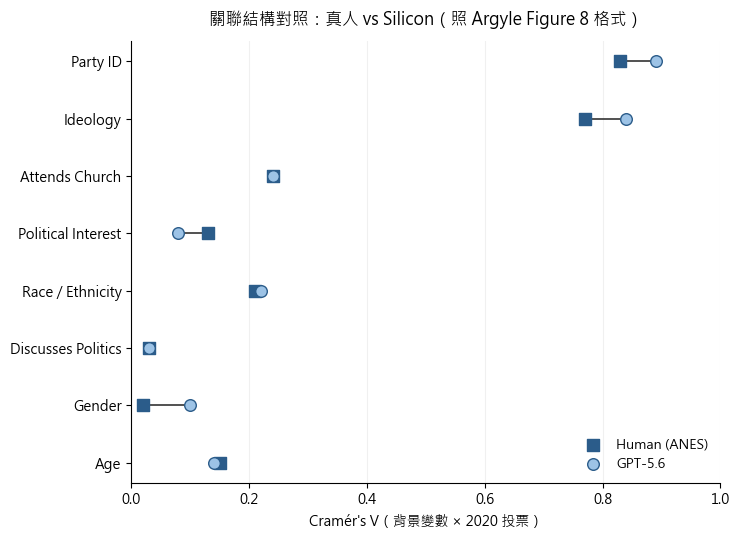

In [ ]:
# -*- coding: utf-8 -*-
# ============================================================
# 分布檢驗（照 Argyle 論文的方法）
# ============================================================
# Argyle 檢驗「模型裝著人群分布」的方法就一套：
# 對每個背景變數，算它跟投票之間的 Cramér's V ——
# 真人資料算一次、silicon 資料算一次，並排比較。
# 兩邊的 V 越接近，代表 silicon 資料裡的變數關聯結構
# 越接近真人（= 分布保真）。
#
# 輸出格式照論文的 Table 11-13：
#   變數 | ANES Cramér's V | GPT Cramér's V | Difference
# 圖照論文的 Figure 8 樣式：每個變數一列，兩個點並排。
#
# 執行：python distribution_validation.py
# 輸出：cramers_v_table.csv + cramers_v_figure.png
# ============================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei", "PingFang TC", "Noto Sans CJK TC",
    "Noto Sans CJK JP", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

RESULT_FILE = "silicon_1000_results.csv"
OUT_CSV = "cramers_v_table.csv"
OUT_PNG = "cramers_v_figure.png"

# ------------------------------------------------------------
# 讀資料 + 從 prompt 解析背景變數
# ------------------------------------------------------------
df = pd.read_csv(RESULT_FILE)
def grab(p, pattern):
    m = re.search(pattern, p)
    return m.group(1) if m else "MISSING"
df["party"]  = df["prompt"].apply(lambda p: grab(p, r"Politically, I am ([^.]+)\."))
df["ideo"]   = df["prompt"].apply(lambda p: grab(p, r"Ideologically, I am ([^.]+)\."))
df["race"]   = df["prompt"].apply(lambda p: grab(p, r"Racially, I am ([^.]+)\."))
df["church"] = df["prompt"].apply(lambda p: "attend" if "I attend church." in p
                                  else ("no" if "do not attend church" in p else "MISSING"))
df["disc"]   = df["prompt"].apply(lambda p: "yes" if "like to discuss politics" in p
                                  else ("no" if "never discuss politics" in p else "MISSING"))
df["interest"] = df["prompt"].apply(lambda p: grab(p, r"I am (very|somewhat|not very|not at all) interested"))
df["gender"] = df["prompt"].apply(lambda p: grab(p, r"I am a (man|woman)\."))
df["age"]    = pd.to_numeric(df["prompt"].apply(lambda p: grab(p, r"I am (-?\d+) years old")),
                             errors="coerce")
# 年齡是連續變數，照 Argyle 分組後才能算 Cramér's V
df["age_group"] = pd.cut(df["age"], [17, 30, 45, 60, 200],
                         labels=["18-30", "31-45", "46-60", "60+"]).astype(str)

# 樣本：真人投兩黨、silicon 有答案（跟主分析同一批）
ana = df[df["anes_vote"].isin([1, 2]) & df["p_trump"].notna()].copy()
ana["vote_human"] = (ana["anes_vote"] == 2).astype(int)      # 真人投票
ana["vote_gpt"] = (ana["p_trump"] > 0.5).astype(int)         # silicon 投票

# ------------------------------------------------------------
# Cramér's V（照 Argyle：基於卡方，吃類別變數）
# ------------------------------------------------------------
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    obs = ct.values.astype(float)
    n = obs.sum()
    expected = np.outer(obs.sum(axis=1), obs.sum(axis=0)) / n
    chi2 = ((obs - expected) ** 2 / expected).sum()
    return np.sqrt(chi2 / n / (min(ct.shape) - 1))

VARIABLES = [
    ("party",     "Party ID"),
    ("ideo",      "Ideology"),
    ("church",    "Attends Church"),
    ("interest",  "Political Interest"),
    ("race",      "Race / Ethnicity"),
    ("disc",      "Discusses Politics"),
    ("gender",    "Gender"),
    ("age_group", "Age"),
]

rows = []
for col, label in VARIABLES:
    sub = ana[ana[col] != "MISSING"]
    v_human = cramers_v(sub[col], sub["vote_human"])
    v_gpt = cramers_v(sub[col], sub["vote_gpt"])
    rows.append({"Variable": label,
                 "ANES Cramér's V": round(v_human, 2),
                 "GPT Cramér's V": round(v_gpt, 2),
                 "Difference": round(v_human - v_gpt, 2)})   # 照論文：ANES 減 GPT

table = pd.DataFrame(rows)
print(table.to_string(index=False))
table.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"\n表已存：{OUT_CSV}")

# ------------------------------------------------------------
# 圖（照論文 Figure 8 樣式：每變數一列，Human 方塊、GPT 圓點）
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 5.5))
y = range(len(table))

for i, (_, r) in enumerate(table.iterrows()):
    ax.plot([r["GPT Cramér's V"], r["ANES Cramér's V"]], [i, i],
            color="#333333", lw=1.2, zorder=1)
ax.scatter(table["ANES Cramér's V"], y, marker="s", s=70,
           color="#2B5C8A", zorder=2, label="Human (ANES)")
ax.scatter(table["GPT Cramér's V"], y, marker="o", s=70,
           color="#9DC3E6", edgecolor="#2B5C8A", zorder=2, label="GPT-5.6")

ax.set_yticks(list(y))
ax.set_yticklabels(table["Variable"], fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 1.0)
ax.set_xlabel("Cramér's V（背景變數 × 2020 投票）", fontsize=10)
ax.set_title("關聯結構對照：真人 vs Silicon（照 Argyle Figure 8 格式）",
             fontsize=12, pad=12)
ax.legend(loc="lower right", fontsize=9.5, frameon=False)
ax.grid(axis="x", color="#F0F0F0", lw=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print(f"圖已存：{OUT_PNG}")

C:\Users\LHH\AppData\Local\Temp\ipykernel_26372\573860167.py:126: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\LHH\AppData\Local\Temp\ipykernel_26372\573860167.py:127: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")


已輸出：comparison_argyle_vs_ours.png


C:\Users\LHH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


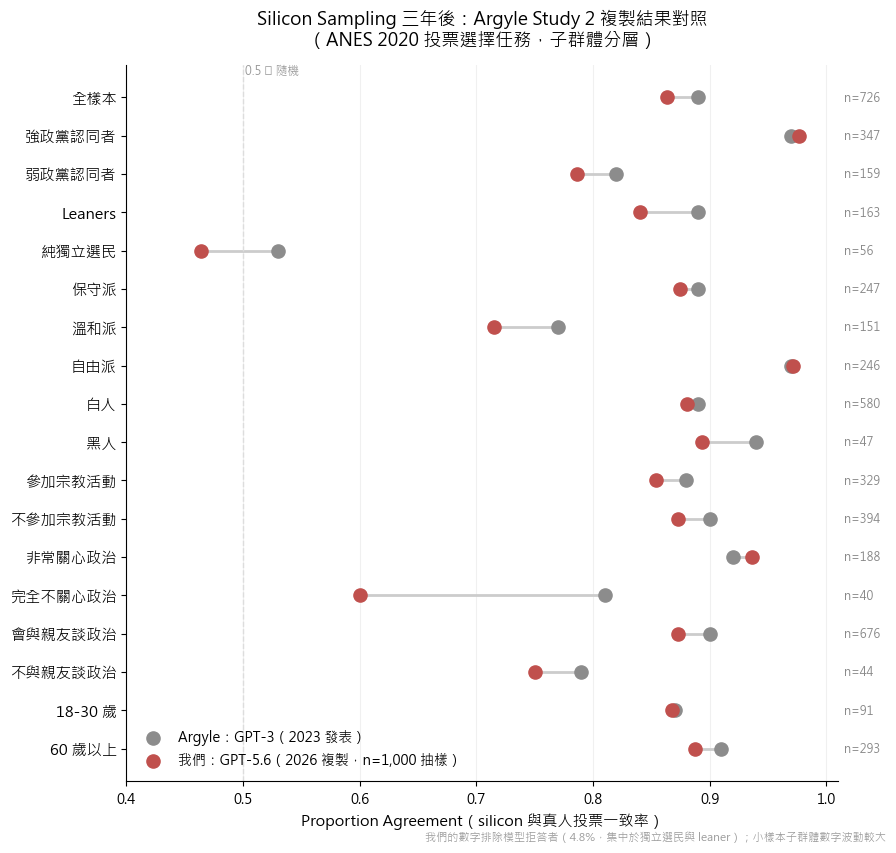

In [6]:
# -*- coding: utf-8 -*-
# ============================================================
# 視覺化：Argyle (GPT-3, 2023) vs 我們 (GPT-5.6, 2026)
# ============================================================
# 讀 silicon_1000_results.csv，畫一張啞鈴圖（dumbbell chart）：
#   每個子群體一列，左右兩點分別是 Argyle Table 9 的 2020 數值
#   和我們的複製結果，中間連線 = 兩代模型的差距。
#
# 執行：python visualize_comparison.py
# 輸出：comparison_argyle_vs_ours.png（300 dpi，可直接進投影片）
# ============================================================

import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 中文字型（依序嘗試：Windows / macOS / Linux）
matplotlib.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei", "PingFang TC", "Noto Sans CJK TC",
    "Noto Sans CJK JP", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

RESULT_FILE = "silicon_1000_results.csv"
OUT_PNG = "comparison_argyle_vs_ours.png"

# ------------------------------------------------------------
# 1. 讀資料，解析子群體（跟驗證程式同一套規則）
# ------------------------------------------------------------
df = pd.read_csv(RESULT_FILE)

def grab(p, pattern):
    m = re.search(pattern, p)
    return m.group(1) if m else "MISSING"

df["party"]  = df["prompt"].apply(lambda p: grab(p, r"Politically, I am ([^.]+)\."))
df["ideo"]   = df["prompt"].apply(lambda p: grab(p, r"Ideologically, I am ([^.]+)\."))
df["race"]   = df["prompt"].apply(lambda p: grab(p, r"Racially, I am ([^.]+)\."))
df["church"] = df["prompt"].apply(lambda p: "attend" if "I attend church." in p
                                  else ("no" if "do not attend church" in p else "MISSING"))
df["disc"]   = df["prompt"].apply(lambda p: "yes" if "like to discuss politics" in p
                                  else ("no" if "never discuss politics" in p else "MISSING"))
df["interest"] = df["prompt"].apply(lambda p: grab(p, r"I am (very|somewhat|not very|not at all) interested"))
df["age"]    = pd.to_numeric(df["prompt"].apply(lambda p: grab(p, r"I am (-?\d+) years old")),
                             errors="coerce").fillna(-1)

# 可比對樣本：真人投兩黨、模型有機率
ana = df[df["anes_vote"].isin([1, 2]) & df["p_trump"].notna()].copy()
ana["gpt_trump"] = (ana["p_trump"] > 0.5).astype(int)
ana["anes_trump"] = (ana["anes_vote"] == 2).astype(int)

# ------------------------------------------------------------
# 2. 每個子群體：(標籤, Argyle 2020 值, 篩選條件)
# ------------------------------------------------------------
SUBGROUPS = [
    ("全樣本",              0.89, ana.index == ana.index),
    ("強政黨認同者",         0.97, ana["party"].isin(["a strong democrat", "a strong Republican"])),
    ("弱政黨認同者",         0.82, ana["party"].isin(["a weak Democrat", "a weak Republican"])),
    ("Leaners",             0.89, ana["party"].isin(["an independent who leans Democratic",
                                                     "an independent who leans Republican"])),
    ("純獨立選民",           0.53, ana["party"] == "an independent"),
    ("保守派",              0.89, ana["ideo"].isin(["slightly conservative", "conservative",
                                                    "extremely conservative"])),
    ("溫和派",              0.77, ana["ideo"] == "moderate"),
    ("自由派",              0.97, ana["ideo"].isin(["slightly liberal", "liberal", "extremely liberal"])),
    ("白人",                0.89, ana["race"] == "white"),
    ("黑人",                0.94, ana["race"] == "black"),
    ("參加宗教活動",         0.88, ana["church"] == "attend"),
    ("不參加宗教活動",       0.90, ana["church"] == "no"),
    ("非常關心政治",         0.92, ana["interest"] == "very"),
    ("完全不關心政治",       0.81, ana["interest"] == "not at all"),
    ("會與親友談政治",       0.90, ana["disc"] == "yes"),
    ("不與親友談政治",       0.79, ana["disc"] == "no"),
    ("18-30 歲",            0.87, (ana["age"] >= 18) & (ana["age"] <= 30)),
    ("60 歲以上",           0.91, ana["age"] > 60),
]
# 註：Hispanics 因 n=16 太小，不放進圖；要放自行加一行即可。

rows = []
for label, argyle, mask in SUBGROUPS:
    sub = ana[mask]
    if len(sub) > 0:
        ours = (sub["gpt_trump"] == sub["anes_trump"]).mean()
        rows.append((label, argyle, ours, len(sub)))

plot_df = pd.DataFrame(rows, columns=["label", "argyle", "ours", "n"])
plot_df = plot_df.iloc[::-1]          # 反轉，讓全樣本畫在最上面

# ------------------------------------------------------------
# 3. 啞鈴圖
# ------------------------------------------------------------
C_ARGYLE = "#8C8C8C"   # 灰：GPT-3 (2023)
C_OURS = "#C0504D"     # 磚紅：GPT-5.6 (2026)

fig, ax = plt.subplots(figsize=(9, 8.5))
y = range(len(plot_df))

for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.plot([r["argyle"], r["ours"]], [i, i], color="#CCCCCC", lw=2, zorder=1)
ax.scatter(plot_df["argyle"], y, s=90, color=C_ARGYLE, zorder=2,
           label="Argyle：GPT-3（2023 發表）")
ax.scatter(plot_df["ours"], y, s=90, color=C_OURS, zorder=2,
           label="我們：GPT-5.6（2026 複製，n=1,000 抽樣）")

# 每列右側標我們的 n
for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.text(1.015, i, f"n={r['n']}", va="center", fontsize=8.5, color="#888888")

ax.set_yticks(list(y))
ax.set_yticklabels(plot_df["label"], fontsize=11)
ax.set_xlim(0.40, 1.01)
ax.set_xlabel("Proportion Agreement（silicon 與真人投票一致率）", fontsize=11)
ax.set_title("Silicon Sampling 三年後：Argyle Study 2 複製結果對照\n"
             "（ANES 2020 投票選擇任務，子群體分層）", fontsize=13, pad=14)
ax.axvline(0.5, color="#DDDDDD", ls="--", lw=1)
ax.text(0.502, len(plot_df) - 0.4, "0.5 ≈ 隨機", fontsize=8.5, color="#999999")
ax.legend(loc="lower left", fontsize=10, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#F0F0F0", lw=0.8)
ax.set_axisbelow(True)

fig.text(0.99, 0.005,
         "我們的數字排除模型拒答者（4.8%，集中於獨立選民與 leaner）；小樣本子群體數字波動較大",
         ha="right", fontsize=8, color="#999999")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print(f"已輸出：{OUT_PNG}")

## 加百列

In [ ]:
# -*- coding: utf-8 -*-
# ============================================================
# GABRIEL 分類實驗：難分的人，換個問法分不分得出來？
# ============================================================
# 用舊檔 silicon_1000_results.csv，不重新生成 persona。
#
# 設計：把每個人的 backstory（prompt 欄，去掉結尾的提問句）
# 直接交給 GABRIEL 當分類任務——「判斷這位選民投 Trump 還是
# Biden」。跟原本的 silicon sampling 是同一個模型、同樣的資訊，
# 唯一差別是任務框架：
#   silicon sampling：第一人稱模擬（「…我投給」讓模型續寫）
#   GABRIEL        ：第三人稱分類（「判斷這個人投誰」）
#
# 要回答的問題：模擬框架下模型「不肯猜」或「猜不好」的人
# （48 個拒答者、獨立選民、猜錯的 99 人），換成分類框架
# 能不能分出來、分得好不好？
#
# 執行前：pip install openai-gabriel，設好 OPENAI_API_KEY
# 執行：python gabriel_readout.py
# 輸出：readout_comparison_report.txt + gabriel_classified.csv
# ============================================================

import asyncio
import re
import pandas as pd
import gabriel

PROB_FILE = "silicon_1000_results.csv"
SAVE_DIR = "./gabriel_vote_classify"         # GABRIEL 存檔目錄（可續跑）
OUT_CSV = "gabriel_classified.csv"
REPORT_FILE = "readout_comparison_report.txt"

# 用跟生成層同一個模型（gpt-5.6 = sol）——這樣兩邊唯一的差別
# 就是任務框架，比較才乾淨
GABRIEL_MODEL = "gpt-5.6"

# ------------------------------------------------------------
# 分類手冊：二元強制選擇（不給「無法判定」，就是要逼它對
# 難分的人下判斷——這正是實驗目的）
# ------------------------------------------------------------
LABELS = {
    "Trump": "Based on the description, this voter most likely voted for "
             "Donald Trump (Republican) in the 2020 US presidential election.",
    "Biden": "Based on the description, this voter most likely voted for "
             "Joe Biden (Democrat) in the 2020 US presidential election.",
}
ADDITIONAL = ("Each text is an anonymized voter profile constructed from "
              "public ANES 2020 survey responses, used for an academic "
              "replication study. The labels are mutually exclusive: assign "
              "exactly one label per profile, giving your best statistical "
              "judgment even when the profile is ambiguous.")
## 每段文字都是依據公開的 ANES 2020 調查回覆所建構的匿名選民輪廓，用於一項學術複製研究。
## 這些標籤互斥：每個輪廓只能指定一個標籤，即使輪廓資訊模糊，也請給出你最好的統計判斷。

def strip_query(prompt):
    """去掉 backstory 結尾的提問句，只留自我描述。"""
    return prompt.split(" In the 2020 presidential election")[0].strip()


def gabriel_to_category(row):
    hits = [lab for lab in LABELS if row.get(lab) is True]
    return hits[0] if len(hits) == 1 else "unclear"


def parse_party(prompt):
    m = re.search(r"Politically, I am ([^.]+)\.", prompt)
    return m.group(1) if m else "MISSING"


async def main():
    lines = []
    def log(msg=""):
        print(msg)
        lines.append(str(msg))

    # ------------------------------------------------------------
    # 1. 準備資料，GABRIEL 分類
    # ------------------------------------------------------------
    df = pd.read_csv(PROB_FILE)
    df["backstory"] = df["prompt"].apply(strip_query)
    df["party"] = df["prompt"].apply(parse_party)

    classified = await gabriel.classify(
        df[["backstory"]].copy(),
        column_name="backstory",
        labels=LABELS,
        additional_instructions=ADDITIONAL,
        model=GABRIEL_MODEL,
        save_dir=SAVE_DIR,
        n_runs=1,
    )
    classified = classified.reset_index(drop=True)
    df = df.reset_index(drop=True)
    df["gabriel_cat"] = classified.apply(gabriel_to_category, axis=1)

    # 機率法的判定（原結果）：p>0.5 = Trump，空值 = 拒答
    df["prob_cat"] = df["p_trump"].apply(
        lambda p: ("Trump" if p > 0.5 else "Biden") if pd.notna(p) else "refusal")
    df["truth"] = df["anes_vote"].map({1: "Biden", 2: "Trump"})
    df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

    log("=" * 60)
    log("任務框架比較：第一人稱模擬（silicon）vs 第三人稱分類（GABRIEL）")
    log("=" * 60)
    log(f"\n[GABRIEL 分類分布]（n={len(df)}）")
    log(df["gabriel_cat"].value_counts().to_string())
    log("  → 第一個檢查點：分類框架下有沒有拒答/無法判定？"
        "（模擬框架下有 48 人拒答）")

    # ------------------------------------------------------------
    # 2. 主結果：兩種框架的 PA 並排
    # ------------------------------------------------------------
    log("\n[主結果對照]（可比對 = 真人投兩黨且該法有答案）")
    for name, col in [("silicon 模擬", "prob_cat"), ("GABRIEL 分類", "gabriel_cat")]:
        sub = df[df["truth"].notna() & df[col].isin(["Trump", "Biden"])]
        pa = (sub[col] == sub["truth"]).mean()
        log(f"  {name:<12} PA = {pa:.3f}  (n={len(sub)})")

    # ------------------------------------------------------------
    # 3. 重點一：模擬框架拒答的 48 人，分類框架處理得如何
    # ------------------------------------------------------------
    refused = df[df["prob_cat"] == "refusal"]
    log(f"\n[拒答者分析] 模擬框架拒答 {len(refused)} 人")
    log("  GABRIEL 對這些人的分類：")
    log(refused["gabriel_cat"].value_counts().to_string())
    r_valid = refused[refused["truth"].notna()
                      & refused["gabriel_cat"].isin(["Trump", "Biden"])]
    if len(r_valid):
        pa_r = (r_valid["gabriel_cat"] == r_valid["truth"]).mean()
        log(f"  其中可對答案的 {len(r_valid)} 人，GABRIEL 猜對率 = {pa_r:.1%}")
        log("  → 模擬不肯猜的人，分類框架不但肯猜，還猜得對不對？")

    # ------------------------------------------------------------
    # 4. 重點二：模擬框架猜錯的人，分類框架救回多少
    # ------------------------------------------------------------
    wrong = df[df["truth"].notna() & df["prob_cat"].isin(["Trump", "Biden"])
               & (df["prob_cat"] != df["truth"])]
    w_valid = wrong[wrong["gabriel_cat"].isin(["Trump", "Biden"])]
    if len(w_valid):
        saved = (w_valid["gabriel_cat"] == w_valid["truth"]).sum()
        log(f"\n[錯誤救援] 模擬框架猜錯 {len(wrong)} 人中，"
            f"GABRIEL 分類救回 {saved} 人（{saved/len(w_valid):.1%}）")

    # 反向：模擬對、分類錯的人數（公平起見兩邊都看）
    right = df[df["truth"].notna() & (df["prob_cat"] == df["truth"])]
    lost = (right["gabriel_cat"].isin(["Trump", "Biden"])
            & (right["gabriel_cat"] != right["truth"])).sum()
    log(f"[反向損失] 模擬猜對的 {len(right)} 人中，GABRIEL 反而分錯 {lost} 人")

    # ------------------------------------------------------------
    # 5. 重點三：按政黨認同分層，看難分的格子
    # ------------------------------------------------------------
    log("\n[分層 PA 對照]（重點看獨立選民與 leaner）")
    party_order = ["a strong democrat", "a weak Democrat",
                   "an independent who leans Democratic", "an independent",
                   "an independent who leans Republican", "a weak Republican",
                   "a strong Republican"]
    log(f"  {'政黨認同':<42}{'模擬':>8}{'分類':>8}{'n':>6}")
    for pt in party_order:
        sub = df[(df["party"] == pt) & df["truth"].notna()]
        s1 = sub[sub["prob_cat"].isin(["Trump", "Biden"])]
        s2 = sub[sub["gabriel_cat"].isin(["Trump", "Biden"])]
        pa1 = (s1["prob_cat"] == s1["truth"]).mean() if len(s1) else float("nan")
        pa2 = (s2["gabriel_cat"] == s2["truth"]).mean() if len(s2) else float("nan")
        log(f"  {pt:<42}{pa1:>8.2f}{pa2:>8.2f}{len(sub):>6}")
    log("  → 判讀：分類框架若在獨立選民格顯著更好（且不拒答），")
    log("    表示模擬框架的弱點是任務框架造成的，不是資訊不足；")
    log("    若一樣差，表示那格就是資訊天花板，換框架也沒用")

    with open(REPORT_FILE, "w", encoding="utf-8-sig") as f:
        f.write("\n".join(lines))
    print(f"\n報告已存：{REPORT_FILE}")
    print(f"逐筆結果已存：{OUT_CSV}")


if __name__ == "__main__":
    try:
        # 終端機執行：python gabriel_readout.py
        asyncio.run(main())
    except RuntimeError:
        # Jupyter / VS Code notebook 已有事件迴圈，asyncio.run 會炸。
        # 在 notebook 裡請不要跑這個區塊，直接在儲存格執行：
        await main()
        print("偵測到 notebook 環境：請在儲存格直接執行  await main()")

[Classify] Found saved labels in gabriel_vote_classify\attributes.json. Using them for consistency.
[Classify] Rendering 971 prompts…
Initializing model calls and loading data...
Installing missing dependencies for GABRIEL (once per session): wheel

===== Run kickoff =====
Prompts: 971 | Words: ~342,014 | Words per prompt: ~352
Model: gpt-5.6 | Reasoning effort: default | Mode: streaming | modality: text
Pricing for model 'gpt-5.6': input $1.25/1M, output $10.0/1M
Estimated token usage: input 512,747, output 485,500 | ~1,528 tokens per call
Estimated synchronous cost: $5.50 (input: $0.64, output: $4.85)

===== Run limits =====
Requests per minute: 500
Tokens per minute: 500,000
Approx. words per minute: 250,000
Note: running at most 327 concurrent requests (vs. 650 requested) because about 499,996 tokens remain in the current minute.

Usage tiers (higher tier = faster runs):
  • Free: qualify by User must be in an allowed geography; monthly quota $100 / month
  • Tier 1: qualify by $5 

Processing prompts:   0%|          | 0/971 [00:00<?, ?it/s]

[parallelization] 2026-08-10 13:40:55 | Initial parallelization settings: cost_so_far=$0.00, p90=unknown, timeouts=0/1, rate_limit_errors=0/1, connection_errors=0/1, json_parse_errors=0/1, tps=unknown, throughput<=278 prompts/min, cap=57, active=0, inflight=0, awaiting_response=0, queue=971, processed=0/971
[parallelization] Ramping up from 56 to 278 parallel threads over 15s.


Processing prompts:  26%|██▌       | 254/971 [00:13<00:21, 33.63it/s]

[dynamic timeout] Initialized timeout to 19.1s (p90=7.7s, factor=2.50).


...

Processing prompts:  34%|███▍      | 333/971 [00:15<00:12, 49.92it/s]

[parallelization] Ramp-up complete at 278 parallel threads.


Processing prompts:  51%|█████     | 495/971 [00:27<00:50,  9.47it/s]2026-08-10 13:41:22,593 - gabriel.utils.openai_utils - WARNING - OpenAI client timed out; consider reducing concurrency. Details: API call exceeded timeout (elapsed 21.70s) (subsequent occurrences of this error will be silenced in logs)
2026-08-10 13:41:22,593 - gabriel.utils.openai_utils - WARNING - First timeout encountered (e17ef33feb5c8ba0_batch0 timed out after 21.70s). Subsequent timeouts will be summarised in periodic status updates.
Processing prompts: 100%|██████████| 971/971 [01:39<00:00,  9.72it/s]
2026-08-10 13:42:35,131 - gabriel.utils.openai_utils - WARNING - 2 timeouts encountered.


Actual total cost: $4.88; average per row: $0.01; average per 1000 rows: $5.02
[Classify] Filled 933/971 unique texts.

=== Label coverage (non-null) ===
Trump                                                  : 96.09% (933/971)
Biden                                                  : 96.09% (933/971)

任務框架比較：第一人稱模擬（silicon）vs 第三人稱分類（GABRIEL）

[GABRIEL 分類分布]（n=1000）
gabriel_cat
Biden      447
Trump      347
unclear    206
  → 第一個檢查點：分類框架下有沒有拒答/無法判定？（模擬框架下有 48 人拒答）

[主結果對照]（可比對 = 真人投兩黨且該法有答案）
  silicon 模擬   PA = 0.864  (n=726)
  GABRIEL 分類   PA = 0.923  (n=611)

[拒答者分析] 模擬框架拒答 48 人
  GABRIEL 對這些人的分類：
gabriel_cat
unclear    28
Trump      15
Biden       5
  其中可對答案的 1 人，GABRIEL 猜對率 = 0.0%
  → 模擬不肯猜的人，分類框架不但肯猜，還猜得對不對？

[錯誤救援] 模擬框架猜錯 99 人中，GABRIEL 分類救回 28 人（44.4%）
[反向損失] 模擬猜對的 627 人中，GABRIEL 反而分錯 11 人

[分層 PA 對照]（重點看獨立選民與 leaner）
  政黨認同                                            模擬      分類     n
  a strong democrat                             0.98    0.98   189
  a weak Democrat              

C:\Users\LHH\AppData\Local\Temp\ipykernel_6668\3599151647.py:183: RuntimeWarning: coroutine 'main' was never awaited
  print("偵測到 notebook 環境：請在儲存格直接執行  await main()")
